# Image Generation with Flow Matching

Extends the 1D FM example from `learn_FM.ipynb` to 28×28 MNIST images.

**The math is identical** — only the model architecture changes (MLP → U-Net):
- Source: $x_0 \sim \mathcal{N}(0, I)$ (Gaussian noise, same shape as image)
- Target: $x_1 \sim p_{\text{data}}$ (real MNIST digit)
- Path: $x_t = (1-t)\, x_0 + t\, x_1$ (straight line)
- Velocity: $v^* = x_1 - x_0$
- Model: $\text{UNet}(x_t, t) \approx v^*$

In [1]:
import sys
sys.path.insert(0, '..')   # so 'image_fm' is importable from learn_FM/

import torch
from image_fm import get_dataloader, UNet, train, sample
from image_fm import plot_loss, plot_samples, plot_denoising_trajectory

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Inspect the data

/Users/lele/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Batch shape: torch.Size([64, 1, 28, 28])
Value range: [-1.00, 1.00]


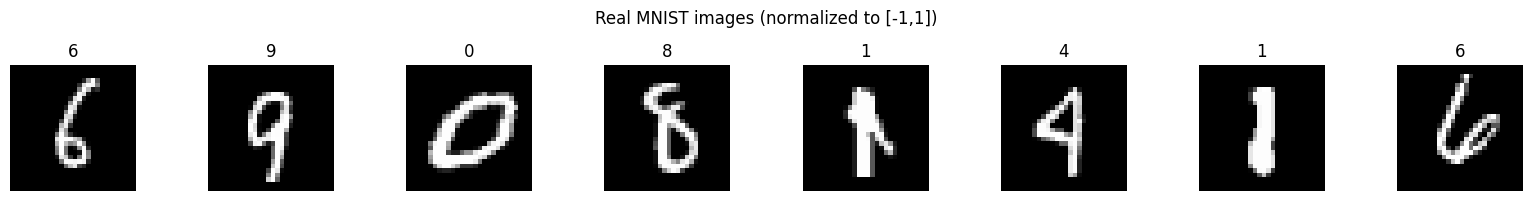

In [2]:
import matplotlib.pyplot as plt
import numpy as np

dataloader = get_dataloader(batch_size=64)
x1_batch, labels = next(iter(dataloader))
print('Batch shape:', x1_batch.shape)   # [64, 1, 28, 28]
print('Value range: [{:.2f}, {:.2f}]'.format(x1_batch.min(), x1_batch.max()))

# Show a few real images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, img, label in zip(axes, x1_batch[:8], labels[:8]):
    ax.imshow((img[0] + 1) / 2, cmap='gray', vmin=0, vmax=1)
    ax.set_title(str(label.item()))
    ax.axis('off')
plt.suptitle('Real MNIST images (normalized to [-1,1])')
plt.tight_layout()
plt.show()

## 2. Inspect the model

In [3]:
model = UNet(in_channels=1, base_channels=32, time_dim=128)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')

# Quick forward pass to verify shapes
x_test = torch.randn(4, 1, 28, 28)
t_test = torch.rand(4, 1)
v_test = model(x_test, t_test)
print('Input shape: ', x_test.shape)
print('Output shape:', v_test.shape)  # should be [4, 1, 28, 28]

Parameters: 819,809
Input shape:  torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 1, 28, 28])


## 3. Train

In [4]:
model, losses = train(
    nb_epochs=10,
    batch_size=128,
    max_samples=1000,
    lr=1e-3,
    base_channels=32,
    time_dim=128,
    checkpoint_dir='checkpoints',
    device=str(DEVICE),
)

Training on cpu


Epoch 1/10: 100%|██████████| 7/7 [00:04<00:00,  1.57it/s, loss=0.8540]


Epoch   1 | avg loss: 1.3874


Epoch 2/10: 100%|██████████| 7/7 [00:04<00:00,  1.57it/s, loss=0.5601]


Epoch   2 | avg loss: 0.6814


...

Epoch   8 | avg loss: 0.3606


Epoch 9/10: 100%|██████████| 7/7 [00:04<00:00,  1.56it/s, loss=0.3446]


Epoch   9 | avg loss: 0.3431


Epoch 10/10: 100%|██████████| 7/7 [00:04<00:00,  1.55it/s, loss=0.3228]

Epoch  10 | avg loss: 0.3383


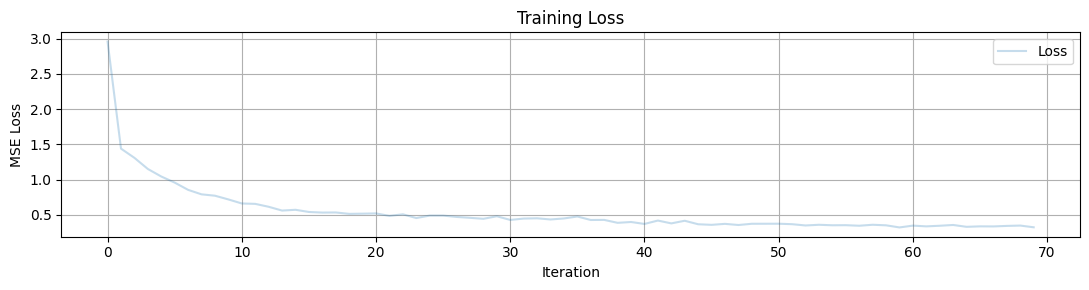

In [5]:
plot_loss(losses)

## 4. Sample: generate images from noise

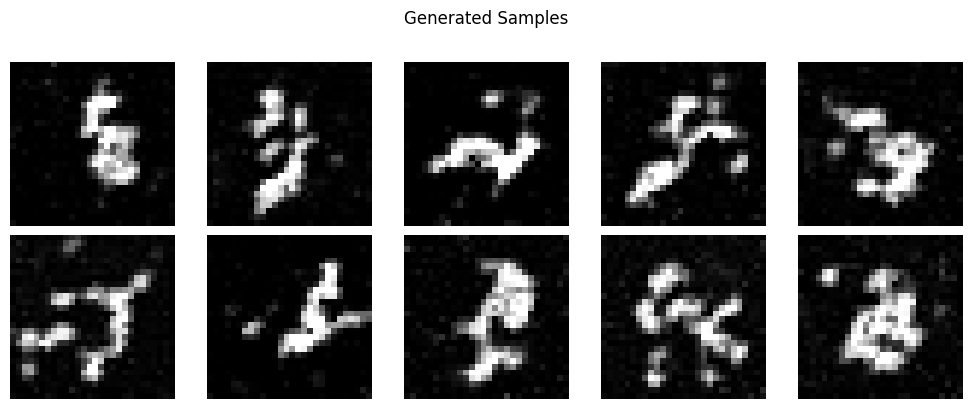

In [6]:
generated = sample(model, n_samples=10, nb_steps=100)
plot_samples(generated, nrow=5)

## 5. Visualize the denoising trajectory

Analogous to the straight-line paths in the 1D notebook — but now for images.

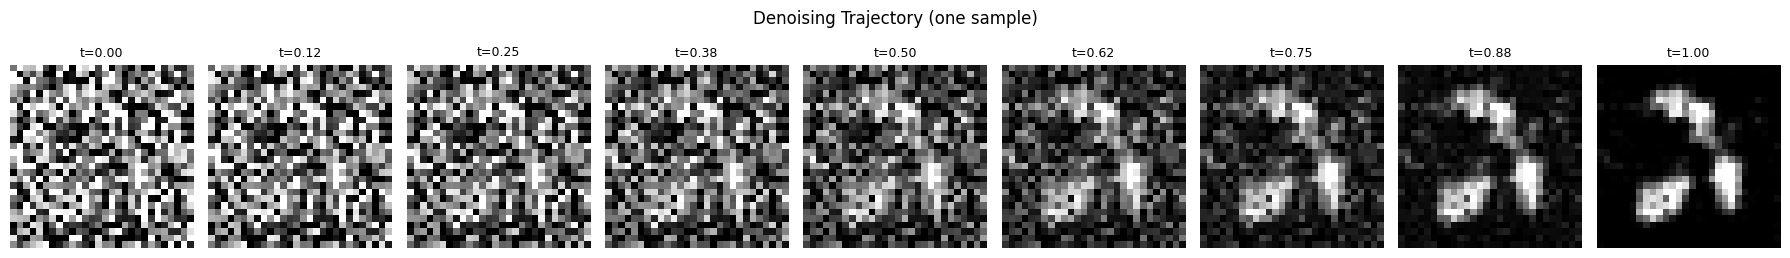

In [7]:
plot_denoising_trajectory(model, nb_steps=8)

---
#  Train on  photos



In [9]:
from image_fm import get_photo_dataloader

photo_dl, in_channels = get_photo_dataloader(
    photo_dir='data/photos',
    image_size=128,       # all images resized to 128
    grayscale=True,     # keep RGB (3 channels); set True for grayscale
    batch_size=2,
    max_samples=None,    # set e.g. 500 to cap for quick tests
)
print('in_channels:', in_channels)

Found 19 images in 'data/photos' → 1ch, 128x128
in_channels: 1


Batch shape: torch.Size([2, 1, 128, 128])


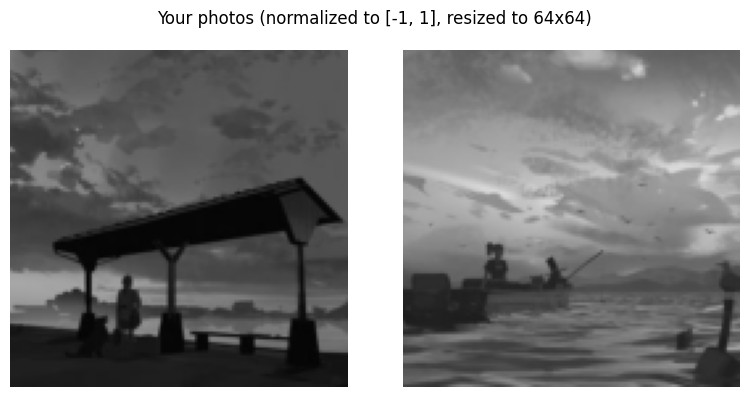

In [10]:
# Peek at a batch
import matplotlib.pyplot as plt
import numpy as np

batch = next(iter(photo_dl))
print('Batch shape:', batch.shape)   # [B, C, 64, 64]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, img in zip(axes, batch[:8]):
    img_show = (img.permute(1, 2, 0).numpy() + 1) / 2   # [-1,1] -> [0,1], HWC
    if img_show.shape[-1] == 1:
        ax.imshow(img_show[:, :, 0], cmap='gray', vmin=0, vmax=1)
    else:
        ax.imshow(img_show.clip(0, 1))
    ax.axis('off')
plt.suptitle('Your photos (normalized to [-1, 1], resized to 64x64)')
plt.tight_layout()
plt.show()

In [11]:
photo_model, photo_losses = train(
    nb_epochs=20,
    lr=1e-3,
    base_channels=32,
    time_dim=128,
    checkpoint_dir='checkpoints_photos',
    device=str(DEVICE),
    dataloader=photo_dl,    # <-- pass your dataloader here
    in_channels=in_channels,  # <-- must match your photos (1 or 3)
)

Training on cpu


Epoch 1/20: 100%|██████████| 10/10 [00:12<00:00,  1.20s/it, loss=0.1445]


Epoch   1 | avg loss: 0.6066


Epoch 2/20: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it, loss=0.4534]


Epoch   2 | avg loss: 0.2633


...

Epoch  18 | avg loss: 0.2259


Epoch 19/20: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it, loss=0.2541]


Epoch  19 | avg loss: 0.2251


Epoch 20/20: 100%|██████████| 10/10 [00:12<00:00,  1.21s/it, loss=0.1621]

Epoch  20 | avg loss: 0.1720


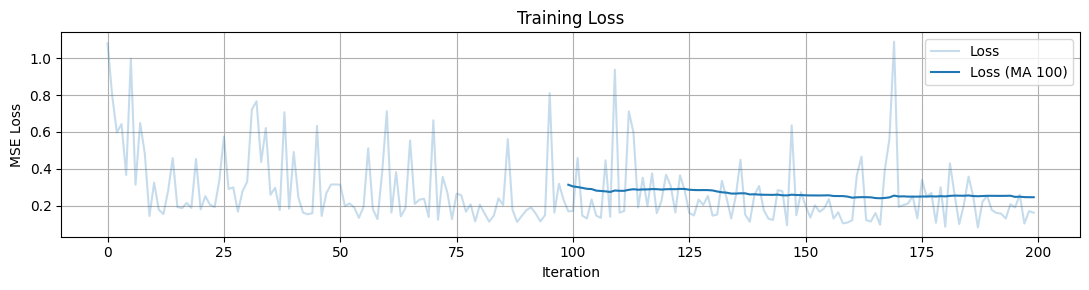

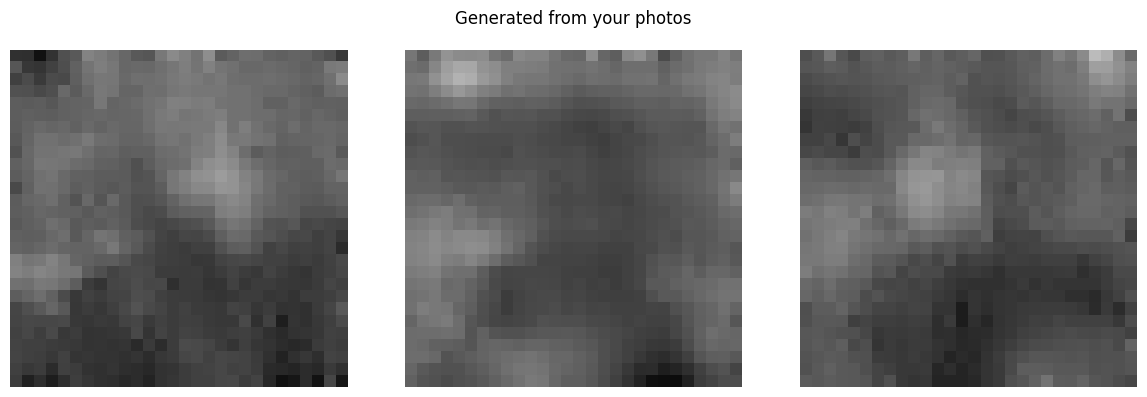

好像是依托啊。。


In [12]:
plot_loss(photo_losses)

generated = sample(photo_model, n_samples=3, nb_steps=100)

# viz: handles both grayscale and RGB
import matplotlib.pyplot as plt
import numpy as np

imgs = (generated.cpu().float() + 1) / 2   # [0,1]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img in zip(axes.reshape(-1), imgs):
    img_show = img.permute(1, 2, 0).numpy()
    if img_show.shape[-1] == 1:
        ax.imshow(img_show[:, :, 0], cmap='gray', vmin=0, vmax=1)
    else:
        ax.imshow(img_show.clip(0, 1))
    ax.axis('off')
plt.suptitle('Generated from your photos')
plt.tight_layout()
plt.show()

print("好像是依托啊。。")